# 🤖 Deep Learning for NLP: Text Classification

**Text Classification** is a core NLP task—assigning categories to text (e.g., sentiment analysis, spam detection, topic labeling).

In this tutorial, you'll build a text classification model using deep learning:
- **Recurrent Neural Networks (RNNs)**
- **Long Short-Term Memory (LSTM)**
- **GloVe word embeddings**

We'll use Keras (TensorFlow), NLTK, and scikit-learn for preprocessing and modeling.

## 🗝️ Key Concepts
- **Text Preprocessing:** Clean and structure raw text for modeling
- **Word Embeddings:** Represent words as dense vectors (GloVe, Word2Vec)
- **LSTM:** A type of RNN for sequence prediction, great for long-term dependencies
- **Model Evaluation:** Use metrics like accuracy, precision, recall, and F1-score

---
This approach enables powerful, context-aware text classification for real-world NLP applications.

# 📝 TextBlob: Overview & Key Features

**TextBlob** is a beginner-friendly Python library for common NLP tasks, built on top of NLTK and Pattern. It offers simple APIs for:

- 🏷️ Part-of-speech tagging
- 📝 Noun phrase extraction
- 😊 Sentiment analysis (polarity & subjectivity)
- 🌍 Translation
- 🗂️ Text classification
- ✂️ Tokenization
- 🌱 Word lemmatization
- 🔍 Spelling correction

**Why use TextBlob?**
- Easy to use for quick NLP prototypes
- Great for learning and small projects

## 🔄 TextBlob vs Other Libraries
- **TextBlob:** Simple, all-in-one, great for beginners
- **NLTK:** More comprehensive, requires more code
- **spaCy:** Fast, advanced, best for large-scale NLP

---
**Summary:** TextBlob is perfect for quick, easy NLP tasks like sentiment analysis, tagging, and translation—ideal for beginners!

---

In [37]:
# import modules
from textblob import TextBlob

In [38]:
# Function for sentiment analysis
def analyze_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    print("Polarity:",polarity)
    if polarity > 0:
        return 'Positive Sentiment'
    elif polarity < 0:
        return 'Negative Sentiment'
    else:
        return 'Neutral Sentiment'

In [39]:
# Example

text = "The weather today is cloudy"
print(text)
print(analyze_sentiment(text))

text = "I love programming, it makes me so happy!"
print(text)
print(analyze_sentiment(text))

The weather today is cloudy
Polarity: 0.0
Neutral Sentiment
I love programming, it makes me so happy!
Polarity: 0.75
Positive Sentiment


In [40]:
# Textblob applications

text = "TextBlob is a great tool for text processing"
blob = TextBlob(text)

# Sentiment analysis
print("\nSentiment:",blob.sentiment)

# Parts-of-speech tagging 
print("\nPOS:",blob.tags)

# Noun phrases extraction
print("\nNouns:",blob.noun_phrases)

# Word tokenization
print("\nWords:",blob.words)

# Sentence tokenization
print("\nSentences:",blob.sentences)

# Spelling correction
text_with_typos = TextBlob("I havv a speling mistake.")
corrected_text = text_with_typos.correct()
print("\nText gave:",text_with_typos)
print("Corrected:",corrected_text)


Sentiment: Sentiment(polarity=0.8, subjectivity=0.75)

POS: [('TextBlob', 'NNP'), ('is', 'VBZ'), ('a', 'DT'), ('great', 'JJ'), ('tool', 'NN'), ('for', 'IN'), ('text', 'NN'), ('processing', 'NN')]

Nouns: ['textblob', 'great tool', 'text processing']

Words: ['TextBlob', 'is', 'a', 'great', 'tool', 'for', 'text', 'processing']

Sentences: [Sentence("TextBlob is a great tool for text processing")]

Text gave: I havv a speling mistake.
Corrected: I have a spelling mistake.


In [41]:
# Tweet Sentiments

tweets =[
    "I love the new iPhone! It's awesome!",
    "I hate this weather, it's so gloomy",
    "This movie was okay, not the best, but decent",
    "I feel amazing today, everything is going great!"
]

for i in tweets:
    blob = TextBlob(i)
    sent = blob.sentiment
    print(f"Tweet: {i}")
    print(f"Sentiment: Polarity = {sent.polarity}, Subjectivity = {sent.subjectivity}")
    print("-"*50)

Tweet: I love the new iPhone! It's awesome!
Sentiment: Polarity = 0.5568181818181818, Subjectivity = 0.6848484848484849
--------------------------------------------------
Tweet: I hate this weather, it's so gloomy
Sentiment: Polarity = -0.8, Subjectivity = 0.9
--------------------------------------------------
Tweet: This movie was okay, not the best, but decent
Sentiment: Polarity = 0.5555555555555556, Subjectivity = 0.48888888888888893
--------------------------------------------------
Tweet: I feel amazing today, everything is going great!
Sentiment: Polarity = 0.8, Subjectivity = 0.825
--------------------------------------------------


# 🤖 Deep Learning for NLP: Building a Text Classification Model

Text classification is a fundamental task in Natural Language Processing (NLP) where the goal is to assign predefined categories or labels to text data. Common applications include:
- **Sentiment Analysis:** Classifying text as positive, negative, or neutral
- **Spam Detection:** Identifying spam vs. non-spam emails
- **Topic Categorization:** Grouping news articles by subject

---

## 🧩 Why Deep Learning for Text Classification?
Traditional machine learning models (like Naive Bayes or SVM) use simple text representations (Bag of Words, TF-IDF). Deep learning models, especially those using word embeddings and sequence models, can capture complex patterns and context in text, leading to better performance on large and complex datasets.

---

## 🗝️ Key Concepts

### 1. Text Preprocessing
Before feeding text to a model, it must be cleaned and structured:
- **Lowercasing**
- **Removing punctuation, numbers, and stopwords**
- **Tokenization:** Splitting text into words or tokens
- **Lemmatization/Stemming:** Reducing words to their base form

### 2. Word Embeddings
Instead of representing words as sparse vectors (one-hot), embeddings map words to dense vectors in a high-dimensional space, capturing semantic relationships. Popular embeddings:
- **GloVe (Global Vectors for Word Representation)**
- **Word2Vec**
- **FastText**

These embeddings allow the model to understand word similarity and context.

### 3. Recurrent Neural Networks (RNNs) & LSTM
- **RNNs** are designed for sequence data, making them ideal for text.
- **LSTM (Long Short-Term Memory)** is a special type of RNN that can capture long-term dependencies and context in sequences, solving the vanishing gradient problem of vanilla RNNs.

### 4. Model Evaluation
To assess model performance, use metrics such as:
- **Accuracy**
- **Precision, Recall, F1-score**
- **Confusion Matrix**

---

## 🛠️ Typical Workflow for Deep Learning Text Classification

1. **Data Collection:** Gather and label your text data (e.g., tweets, reviews).
2. **Text Preprocessing:** Clean and tokenize the text, remove stopwords, and lemmatize/stem words.
3. **Text to Sequences:** Convert words to integer sequences using a tokenizer.
4. **Embedding Layer:** Use pre-trained embeddings (like GloVe) or train your own.
5. **Model Building:**
    - Use Keras (TensorFlow) to build a model with an Embedding layer, LSTM (or GRU), and Dense output layer.
6. **Model Training:** Train the model on your data, monitor loss and accuracy.
7. **Evaluation:** Test the model on unseen data and analyze performance metrics.
8. **Prediction:** Use the trained model to classify new text samples.

---

## 📦 Libraries Used
- **Keras/TensorFlow:** For building and training deep learning models
- **NLTK:** For text preprocessing (tokenization, stopword removal, lemmatization)
- **scikit-learn:** For splitting data, evaluation metrics

---

## 🚀 Advantages of Deep Learning for NLP
- Learns complex patterns and context in text
- Handles large and diverse datasets
- Can leverage pre-trained embeddings for better generalization

---

Deep learning models, especially with LSTM and word embeddings, are state-of-the-art for many NLP tasks and enable powerful, context-aware text classification for real-world applications.

In [53]:
# import modules
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split 
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

In [70]:
# Load dataset

# https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
df = pd.read_csv('imdb.csv') 

df = df.sample(n=1000)
df.to_csv('imdb-sample.csv',index=False)

df = pd.read_csv('imdb-sample.csv') 

In [71]:
# Clean data

stop_words = set(stopwords.words('english')) 

def clean_text(text): 
    text = text.lower()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words) 
 
df['cleaned_review'] = df['review'].apply(clean_text) 
print(df.head())

                                              review sentiment  \
0  I would like to make it very clear that I am n...  negative   
1  I don't know anything of the writer's or the d...  negative   
2  I might have given this movie a higher rating ...  negative   
3  Should this be an American movie I'd rate it 7...  positive   
4  Storyline drags. Drug smugglers a Beautiful wo...  negative   

                                      cleaned_review  
0  would like make clear religious. atheist could...  
1  know anything writer's director's earlier work...  
2  might given movie higher rating peter jackson'...  
3  american movie rate 7: seen before. argentinea...  
4  storyline drags. drug smugglers beautiful wome...  


In [74]:
# Tokenizing & Padding

tokenizer = Tokenizer(num_words=10000) 
tokenizer.fit_on_texts(df['cleaned_review']) 

X = tokenizer.texts_to_sequences(df['cleaned_review']) 
X_pad = pad_sequences(X, padding='post', maxlen=500)  
print(X_pad[:5])

[[  10    5   23 ...    0    0    0]
 [  43  147 5029 ...    0    0    0]
 [ 119  278    2 ...    0    0    0]
 [ 234    2  811 ...    0    0    0]
 [ 814 2722 1051 ...    0    0    0]]


In [75]:
# Encoding

label_encoder = LabelEncoder() 
y = label_encoder.fit_transform(df['sentiment']) 
print(y[:5])

[0 0 0 1 0]


In [76]:
# Model

model = Sequential() 

model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=50),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

c:\Users\Priyanshu\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [77]:
# Train model

X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42) 
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 956ms/step - accuracy: 0.5212 - loss: 0.6935 - val_accuracy: 0.5200 - val_loss: 0.6929
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.4848 - loss: 0.6936 - val_accuracy: 0.4750 - val_loss: 0.6937
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.4637 - loss: 0.6936 - val_accuracy: 0.4750 - val_loss: 0.6965
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.5088 - loss: 0.6937 - val_accuracy: 0.4750 - val_loss: 0.6939
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5033 - loss: 0.6932 - val_accuracy: 0.4800 - val_loss: 0.6932
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5267 - loss: 0.6931 - val_accuracy: 0.4750 - val_loss: 0.6956
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.4936 - loss: 0.6930 - val_accuracy: 0.4750 - val_loss: 0.6942
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.5128 - loss: 0.6933 - val_accuracy: 0.4750 - val_lo

In [78]:
# Evaluate

loss, accuracy = model.evaluate(X_test, y_test) 
print(f"Test Loss: {loss}") 
print(f"Test Accuracy: {accuracy}") 

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.4989 - loss: 0.6935
Test Loss: 0.6934981346130371
Test Accuracy: 0.4749999940395355


In [81]:
# New text for prediction 

new_text = ["I really not enjoyed the movie, it was horrible!"] 

new_text_cleaned = [clean_text(text) for text in new_text] 
new_text_seq = tokenizer.texts_to_sequences(new_text_cleaned) 
new_text_pad = pad_sequences(new_text_seq, padding='post', maxlen=50)

prediction = model.predict(new_text_pad) 
print("Predicted Sentiment:", "Positive" if prediction > 0.5 else "Negative") 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Sentiment: Negative


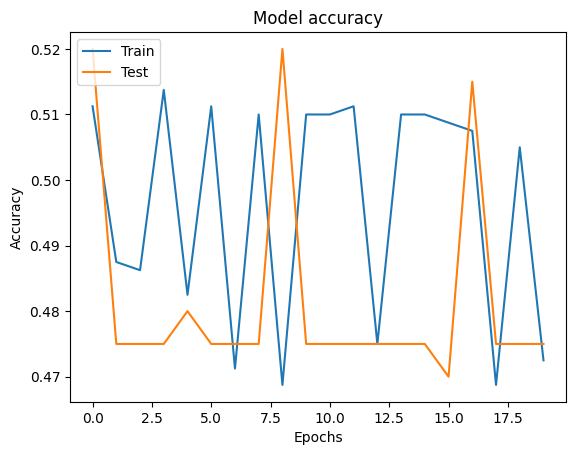

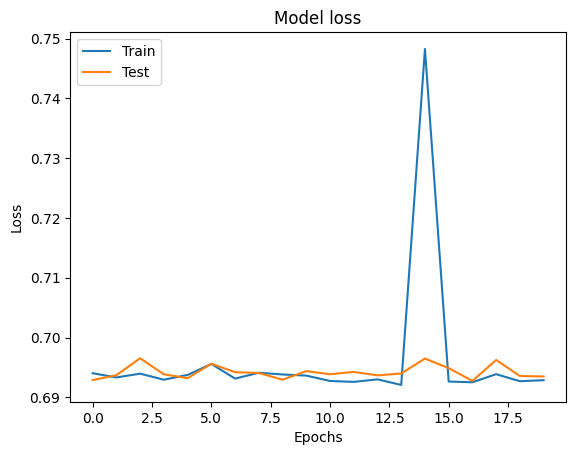

In [82]:
# Plotting

plt.plot(history.history['accuracy']) 
plt.plot(history.history['val_accuracy']) 
plt.title('Model accuracy') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.legend(['Train', 'Test'], loc='upper left') 
plt.show() 

plt.plot(history.history['loss']) 
plt.plot(history.history['val_loss']) 
plt.title('Model loss') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend(['Train', 'Test'], loc='upper left') 
plt.show()